In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.5 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.5 MB/s eta 0:00:00


In [ ]:
!pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import contractions

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec
from collections import Counter

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download('punkt_tab')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI Sem6/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv")
print(df.head())
print("Shape:", df.shape)
print(df["is_sarcastic"].value_counts())

                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1
Shape: (28619, 2)
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


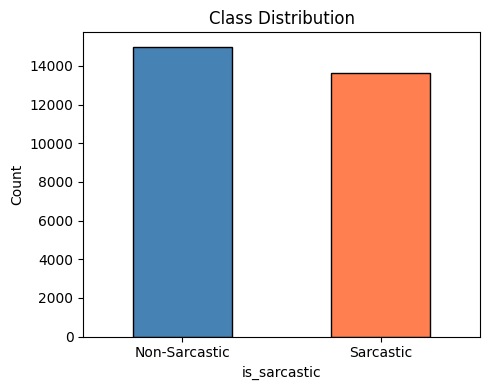

In [ ]:
plt.figure(figsize=(5, 4))
df["is_sarcastic"].value_counts().plot(kind="bar", color=["steelblue", "coral"],
                                        edgecolor="black")
plt.xticks([0, 1], ["Non-Sarcastic", "Sarcastic"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

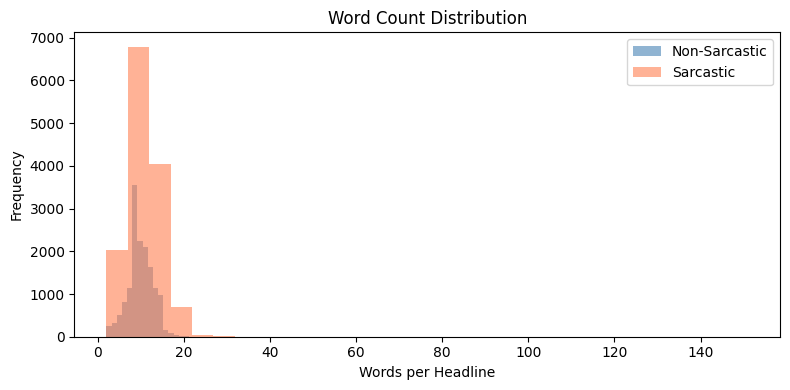

In [ ]:
df["word_count"] = df["headline"].str.split().str.len()

plt.figure(figsize=(8, 4))
for label, name, color in [(0, "Non-Sarcastic", "steelblue"),
                            (1, "Sarcastic", "coral")]:
    plt.hist(df[df["is_sarcastic"] == label]["word_count"],
             bins=30, alpha=0.6, label=name, color=color)
plt.title("Word Count Distribution")
plt.xlabel("Words per Headline")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

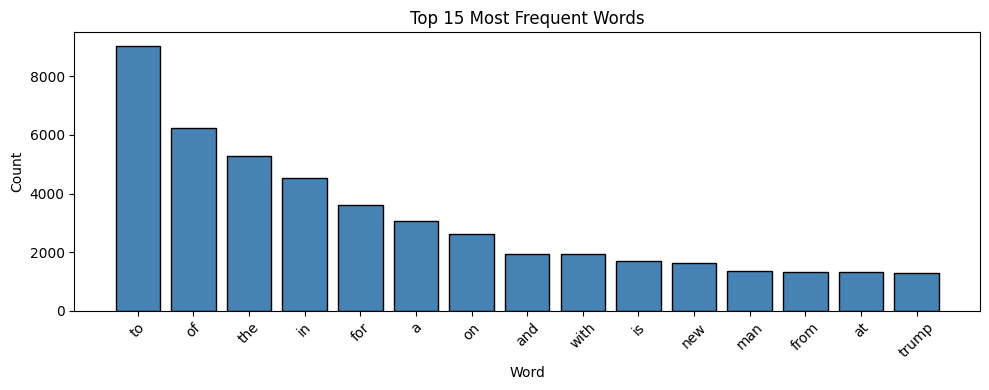

In [ ]:
all_words = " ".join(df["headline"]).lower().split()
word_freq = Counter(all_words).most_common(15)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 4))
plt.bar(words, counts, color="steelblue", edgecolor="black")
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [ ]:
def clean_text(text):
    text = text.lower()                                  # lowercase
    text = contractions.fix(text)                        # don't → do not
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                     # remove mentions
    text = re.sub(r"#\w+", "", text)                     # remove hashtags
    text = re.sub(r"\d+", "", text)                      # remove numbers
    text = re.sub(r"[^a-z\s]", "", text)                 # remove special chars
    text = re.sub(r"\s+", " ", text).strip()             # clean whitespace

    tokens = word_tokenize(text)                         # tokenize
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize
    return " ".join(tokens)

df["clean_headline"] = df["headline"].astype(str).apply(clean_text)

### 4.5.1 Word Cloud Visualization

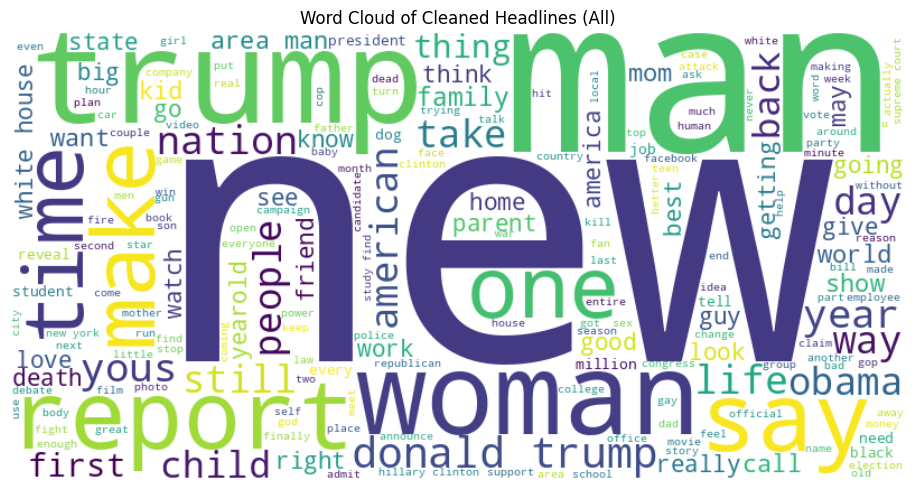

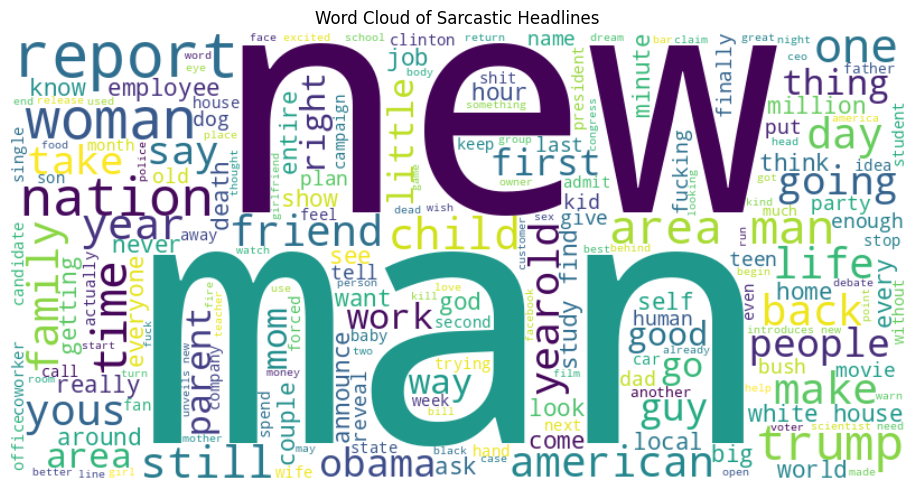

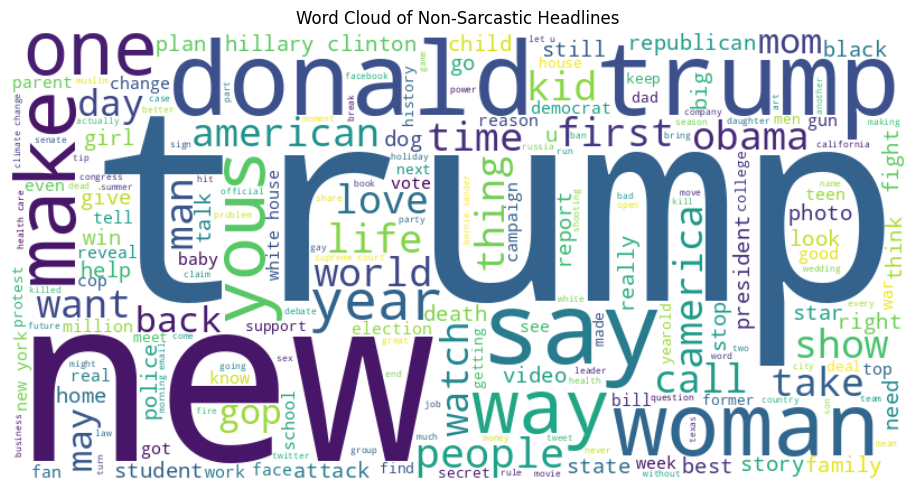

In [ ]:
from wordcloud import WordCloud

clean_text_all = " ".join(df["clean_headline"].dropna())
wc = WordCloud(width=800, height=400, background_color="white").generate(clean_text_all)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Headlines (All)")
plt.tight_layout()
plt.show()

sarcastic_headlines = " ".join(df[df["is_sarcastic"] == 1]["clean_headline"].dropna())
non_sarcastic_headlines = " ".join(df[df["is_sarcastic"] == 0]["clean_headline"].dropna())

wc_sarcastic = WordCloud(width=800, height=400, background_color="white").generate(sarcastic_headlines)
plt.figure(figsize=(12, 5))
plt.imshow(wc_sarcastic, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Sarcastic Headlines")
plt.tight_layout()
plt.show()

wc_non_sarcastic = WordCloud(width=800, height=400, background_color="white").generate(non_sarcastic_headlines)
plt.figure(figsize=(12, 5))
plt.imshow(wc_non_sarcastic, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Non-Sarcastic Headlines")
plt.tight_layout()
plt.show()

In [ ]:
df.head(10)

,headline,is_sarcastic,word_count,clean_headline
0,thirtysomething scientists unveil doomsday clo...,1,8,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,0,13,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,0,7,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,1,8,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,1,9,mother come pretty close using word streaming ...
5,my white inheritance,0,3,white inheritance
6,5 ways to file your taxes with less stress,0,9,way file tax less stress
7,richard branson's global-warming donation near...,1,13,richard bransons globalwarming donation nearly...
8,shadow government getting too large to meet in...,1,12,shadow government getting large meet marriott ...
9,lots of parents know this scenario,0,6,lot parent know scenario


In [ ]:
print("\nBefore:", df["headline"][0])
print("After :", df["clean_headline"][0])


Before: thirtysomething scientists unveil doomsday clock of hair loss
After : thirtysomething scientist unveil doomsday clock hair loss


In [ ]:
MAX_VOCAB = 20000
EMBED_DIM = 64
X = df["clean_headline"].values
y = df["is_sarcastic"].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)

In [ ]:
lengths = [len(s.split()) for s in X_train]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"MAX_LEN (95th percentile): {MAX_LEN}")

MAX_LEN (95th percentile): 11


In [ ]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [ ]:
def encode(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_pad = encode(X_train)
X_test_pad  = encode(X_test)

print("X_train_pad shape:", X_train_pad.shape)
print("Vocab size:", len(tokenizer.word_index))

X_train_pad shape: (22895, 11)
Vocab size: 22522


Model-1: Simple RNN

In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,
                             restore_best_weights=True, verbose=1)]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7412 - loss: 0.5079 - val_accuracy: 0.8066 - val_loss: 0.4124
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9227 - loss: 0.1998 - val_accuracy: 0.7961 - val_loss: 0.5198
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9789 - loss: 0.0592 - val_accuracy: 0.7921 - val_loss: 0.8044
Epoch 4/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accuracy: 0.7843 - val_loss: 0.8263
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


Model-2: LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [ ]:
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,restore_best_weights=True, verbose=1)]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7384 - loss: 0.5084 - val_accuracy: 0.8074 - val_loss: 0.4215
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8867 - loss: 0.2730 - val_accuracy: 0.7921 - val_loss: 0.5121
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9469 - loss: 0.1461 - val_accuracy: 0.7834 - val_loss: 0.6860
Epoch 4/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9690 - loss: 0.0899 - val_accuracy: 0.7738 - val_loss: 0.8590
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


Word2Vec Train

In [ ]:
tokenized_train = [s.split() for s in X_train]
w2v_model = Word2Vec(sentences=tokenized_train, vector_size=EMBED_DIM,window=5, min_count=1, workers=4, seed=SEED)

Embedding Matrix

In [ ]:
vocab_size    = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
embed_matrix  = np.zeros((vocab_size, EMBED_DIM))

for word, idx in tokenizer.word_index.items():
    if idx < vocab_size and word in w2v_model.wv:
        embed_matrix[idx] = w2v_model.wv[word]

w2v_lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN,
              weights=[embed_matrix], trainable=False),   # frozen pretrained weights
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [ ]:
w2v_lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
w2v_lstm_model.summary()

w2v_history = w2v_lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3,
                             restore_best_weights=True, verbose=1)]
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,280,000 (4.88 MB)

Epoch 1/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5685 - loss: 0.6781 - val_accuracy: 0.5817 - val_loss: 0.6774
Epoch 2/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6165 - loss: 0.6496 - val_accuracy: 0.6000 - val_loss: 0.6569
Epoch 3/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6244 - loss: 0.6354 - val_accuracy: 0.5987 - val_loss: 0.6530
Epoch 4/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6285 - loss: 0.6304 - val_accuracy: 0.6031 - val_loss: 0.6499
Epoch 5/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6334 - loss: 0.6259 - val_accuracy: 0.6039 - val_loss: 0.6447
Epoch 6/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6343 - loss: 0.6228 - val_accuracy: 0.6223 - val_loss: 0.6295
Epoch 7/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6395 - loss: 0.6186 - val_accuracy: 0.6223 - val_loss: 0.6270
Epoch 8/40
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6442 - loss: 0.6157 - val_accuracy: 

Training Curve: All 2 Models

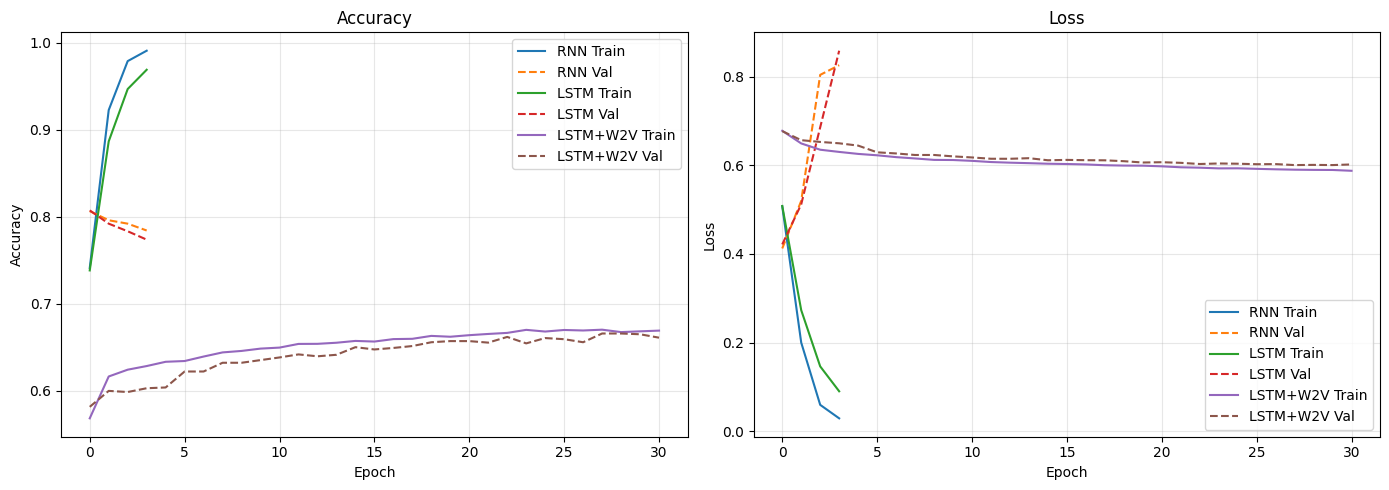

In [ ]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for hist, name in zip(histories, names):
        axes[0].plot(hist.history["accuracy"],label=f"{name} Train")
        axes[0].plot(hist.history["val_accuracy"],label=f"{name} Val", linestyle="--")
        axes[1].plot(hist.history["loss"],label=f"{name} Train")
        axes[1].plot(hist.history["val_loss"],label=f"{name} Val", linestyle="--")

    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history([rnn_history, lstm_history, w2v_history],["RNN", "LSTM", "LSTM+W2V"])

Evaluate All Model


  Simple RNN
  Loss: 0.4240 | Accuracy: 0.7982
               precision    recall  f1-score   support

Non-Sarcastic       0.77      0.87      0.82      2997
    Sarcastic       0.84      0.72      0.77      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.79      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



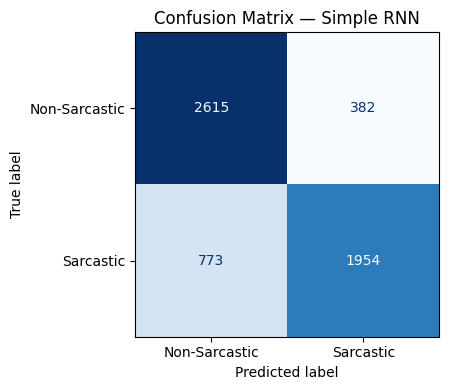


  LSTM
  Loss: 0.4297 | Accuracy: 0.7900
               precision    recall  f1-score   support

Non-Sarcastic       0.77      0.86      0.81      2997
    Sarcastic       0.82      0.71      0.76      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



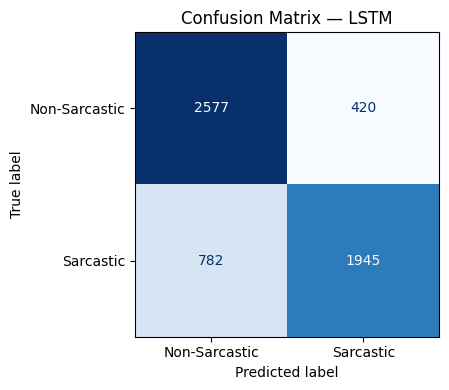


  LSTM + Word2Vec
  Loss: 0.6083 | Accuracy: 0.6490
               precision    recall  f1-score   support

Non-Sarcastic       0.64      0.75      0.69      2997
    Sarcastic       0.66      0.54      0.59      2727

     accuracy                           0.65      5724
    macro avg       0.65      0.64      0.64      5724
 weighted avg       0.65      0.65      0.64      5724



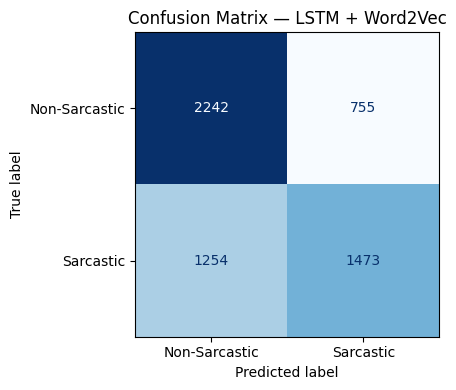

In [ ]:
def evaluate_model(model, name, X_test, y_test):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  Loss: {loss:.4f} | Accuracy: {acc:.4f}")
    y_pred = (model.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
    print(classification_report(y_test, y_pred,target_names=["Non-Sarcastic", "Sarcastic"]))
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Sarcastic", "Sarcastic"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout(); plt.show()
    return y_pred

rnn_pred  = evaluate_model(rnn_model,      "Simple RNN",    X_test_pad, y_test)
lstm_pred = evaluate_model(lstm_model,     "LSTM",          X_test_pad, y_test)
w2v_pred  = evaluate_model(w2v_lstm_model, "LSTM + Word2Vec", X_test_pad, y_test)

Error Analysis

In [ ]:
def error_analysis(y_test, y_pred, X_test_raw, model_name, n=3):
    print(f"\n── Misclassified Examples ({model_name}) ──────────────")
    errors = np.where(y_test != y_pred)[0]
    for i in errors[:n]:
        actual    = "Sarcastic" if y_test[i] == 1 else "Non-Sarcastic"
        predicted = "Sarcastic" if y_pred[i] == 1 else "Non-Sarcastic"
        print(f"  Headline  : {X_test_raw[i]}")
        print(f"  Actual    : {actual}")
        print(f"  Predicted : {predicted}\n")

error_analysis(y_test, lstm_pred, X_test, "LSTM")


── Misclassified Examples (LSTM) ──────────────
  Headline  : group christie campaign deserter found forest
  Actual    : Sarcastic
  Predicted : Non-Sarcastic

  Headline  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  Actual    : Sarcastic
  Predicted : Non-Sarcastic

  Headline  : rex tillerson call report ouster laughable
  Actual    : Non-Sarcastic
  Predicted : Sarcastic



### 4.5.4 Written Error Analysis and Model Comparison

In [ ]:
import gradio as gr

def predict(headline):
    cleaned = clean_text(headline)
    padded  = encode([cleaned])
    prob    = lstm_model.predict(padded, verbose=0)[0][0]
    print(f"Raw prob: {prob}")
    label   = "Sarcastic" if prob >= 0.5 else "Non-Sarcastic"
    return f"{label} (confidence: {prob:.2f})"

print(predict("oh great another monday"))
print(predict("wow what a brilliant idea"))
print(predict("yeah sure that totally worked"))
print(predict("thirtysomething scientists unveil doomsday clock"))

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter a headline"),
    outputs=gr.Textbox(label="Prediction"),
    title="Sarcasm Detector",
    description="Type a headline and find out if it's sarcastic!"
)

demo.launch()

Raw prob: 0.08308068662881851
Non-Sarcastic (confidence: 0.08)
Raw prob: 0.22386828064918518
Non-Sarcastic (confidence: 0.22)
Raw prob: 0.5624825954437256
Sarcastic (confidence: 0.56)
Raw prob: 0.709103524684906
Sarcastic (confidence: 0.71)
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fce7868ca803f04674.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
